# Controlled Trajectory Examples: 4 — Mass-Spring-Damper Chain

This is the **fourth and final example** in the controlled-trajectory
progression.  The third example
showed a single-agent system with physically coupled state coordinates.
Here we return to a **graph-structured mechanical system**: a chain of
masses connected by springs and dampers.

## Physical system

Two unit masses are connected in a chain anchored to a fixed wall at the
left end.  Each mass can be driven by an external force:

```
  wall ─[k,c]─ m₁ ─[k,c]─ m₂
                ↑             ↑
               u₁            u₂
```

With per-mass state $x_i = [x_i, \dot{x}_i]^\top$ stacked as
$x = [x_1, \dot{x}_1, x_2, \dot{x}_2]^\top$,
and control $u = [u_1, u_2]^\top$, Newton's second law gives
$\dot{x} = A_c x + B_c u$ with

$$
A_c = \begin{bmatrix}
  0   & 1    & 0  & 0  \\
  -2k & -2c  & k  & c  \\
  0   & 0    & 0  & 1  \\
  k   & c    & -k & -c
\end{bmatrix},
\qquad
B_c = \begin{bmatrix} 0 & 0 \\ 1 & 0 \\ 0 & 0 \\ 0 & 1 \end{bmatrix}.
$$

### Why the diagonal blocks are different

Mass 1 is attached to **both** the fixed wall and mass 2, giving three
force contributions to its velocity equation:

$$
\ddot{x}_1 = \underbrace{-k x_1 - c \dot{x}_1}_{\text{wall spring/damper}}
           + \underbrace{k(x_2 - x_1) + c(\dot{x}_2 - \dot{x}_1)}_{\text{inter-mass coupling}}
           + u_1
           = -2k x_1 - 2c \dot{x}_1 + k x_2 + c \dot{x}_2 + u_1.
$$

Mass 2 is attached only to mass 1 (free right end), so it has two contributions:

$$
\ddot{x}_2 = \underbrace{k(x_1 - x_2) + c(\dot{x}_1 - \dot{x}_2)}_{\text{inter-mass coupling}}
           + u_2
           = k x_1 + c \dot{x}_1 - k x_2 - c \dot{x}_2 + u_2.
$$

The coefficients $(-2k, -2c)$ in mass 1's row versus $(-k, -c)$ in mass 2's
row reflect this asymmetry: mass 1 is "grounded" at the wall, while mass 2 is free.
The coupling submatrix for positions is the **grounded Laplacian**
$\hat{L} = \begin{bmatrix} 2k & -k \\ -k & k \end{bmatrix}$, which equals the
standard path-graph Laplacian $k \begin{bmatrix} 1 & -1 \\ -1 & 1 \end{bmatrix}$
plus a diagonal "anchor" term $k \operatorname{diag}(1, 0)$ for the wall attachment.
The off-diagonal coupling blocks are symmetric by Newton's third law.

**References:**
- Olfati-Saber, R. & Murray, R. M. (2004). "Consensus Problems in Networks of
  Agents with Switching Topology and Time-Delays." *IEEE Transactions on
  Automatic Control*, 49(9), 1520–1533.
  [DOI:10.1109/TAC.2004.834113](https://doi.org/10.1109/TAC.2004.834113)
- Lewis, F. L., Vrabie, D. L., & Syrmos, V. L. (2012). *Optimal Control*, 3rd ed.
  John Wiley & Sons. ISBN 978-0-470-63349-6.

In [1]:
using CellularSheaves
using LinearAlgebra
using BlockArrays
using Plots
using SparseArrays

## Step 1: Physical parameters and continuous-time model

In [2]:
k_spring = 1.0   # spring constant  (N/m)
c_damp   = 0.2   # damper coefficient (N·s/m)
mass     = 1.0   # mass of each particle (kg)

Ac = [0.0          1.0         0.0          0.0;
      -2k_spring  -2c_damp     k_spring     c_damp;
       0.0         0.0         0.0          1.0;
       k_spring    c_damp     -k_spring    -c_damp]

Bc = [0.0          0.0;
      1.0/mass     0.0;
      0.0          0.0;
      0.0          1.0/mass]

println("State dimension  n = ", size(Ac, 1))
println("Control dimension m = ", size(Bc, 2))

State dimension  n = 4
Control dimension m = 2


Verify the grounded-Laplacian structure of the position coupling:
In the second-order form, the acceleration contains the term -L̂ * x,
so the (velocity rows, position columns) block of Ac equals -L̂.

In [3]:
L_hat = Ac[[2, 4], [1, 3]]
println("Position coupling block (should equal -L̂):\n", L_hat)

Position coupling block (should equal -L̂):
[-2.0 1.0; 1.0 -1.0]


In [4]:
L̂_expected = k_spring .* [2.0 -1.0; -1.0 1.0]
@assert L_hat ≈ -L̂_expected "Grounded-Laplacian structure does not match expected pattern (sign convention)"

## Step 2: Build the ControlledTrajectorySheaf

We use a two-vertex base sheaf, one vertex per mass.  Each vertex carries a
2-dimensional stalk (position and velocity), giving a total state dimension
of 4.  This mirrors the structure of the spring network: the two-vertex
base sheaf has the same topology as the path graph $1 - 2$.

In [5]:
h = 0.5    # sample period (seconds)
k = 10     # number of time steps

F  = EuclideanSheaf{Float64}([2, 2])   # two vertices, each 2D (pos, vel)
ts = ControlledTrajectorySheaf(F, Ac, Bc, h, k)

n     = ts.state_dim    # 4
m_dim = ts.control_dim  # 2

println("ZOH step h = ", h, " s,  steps k = ", k)

ZOH step h = 0.5 s,  steps k = 10


## Step 3: Fix endpoint states

Both masses start at rest at natural length.  We push them to a compressed
configuration and return them to rest at a displaced equilibrium.

In [6]:
x1  = [0.0, 0.0, 0.0, 0.0]   # at rest at natural length
xk1 = [0.5, 0.0, 1.0, 0.0]   # mass 1 at 0.5 m, mass 2 at 1.0 m, both at rest

4-element Vector{Float64}:
 0.5
 0.0
 1.0
 0.0

## Step 4: Assemble the LQR objective

In [7]:
Q  = Matrix{Float64}(I, n, n)
Ru = Matrix{Float64}(I, m_dim, m_dim)
Qf = 5.0 * Matrix{Float64}(I, n, n)

H, f, _ = lqr_objective(ts, Q, Ru; Qf=Qf)

(sparse([1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  55, 56, 57, 58, 59, 60, 61, 62, 63, 64], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  55, 56, 57, 58, 59, 60, 61, 62, 63, 64], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 64, 64), [-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0  …  -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0], 0.0)

Visualize the block-diagonal structure of H.
The state trajectory has (k+1) blocks of size 4 and k control blocks of
size 2, giving H of size ((k+1)*4 + k*2) × ((k+1)*4 + k*2) = 64×64.
The upper-left square carries the state weights Q (×k) and Qf (terminal);
the lower-right square carries the control weights Ru (×k).

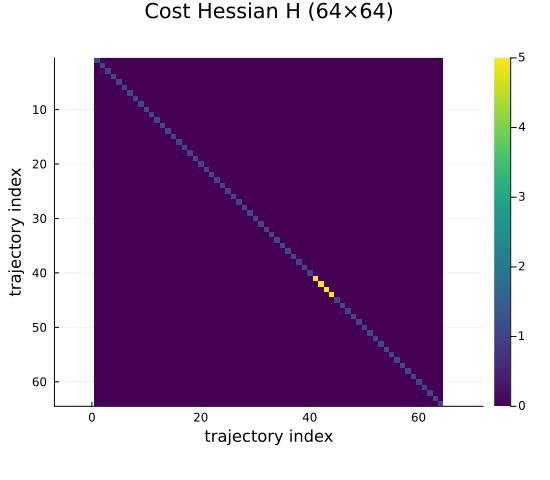

In [8]:
p_H = heatmap(Matrix(H);
    color=:viridis, colorbar=true,
    title="Cost Hessian H ($(size(H,1))×$(size(H,2)))",
    xlabel="trajectory index", ylabel="trajectory index",
    yflip=true, aspect_ratio=:equal, size=(550, 480))
p_H

## Step 5: Solve for the optimal trajectory

In [9]:
z_opt, α_opt, z_p, null_basis = optimal_control_trajectory(ts, x1, xk1, H, f)

println("Free parameters r = ", size(null_basis, 2))

Free parameters r = 10


## Step 6: Plot positions and control inputs

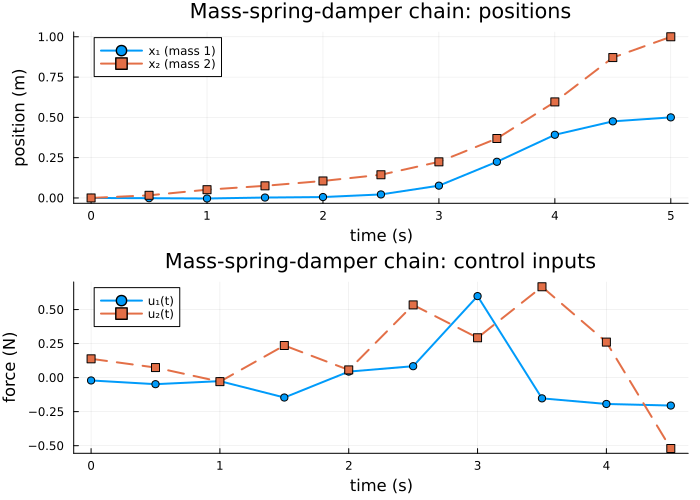

In [10]:
times_state   = h .* (0:k)
times_control = h .* (0:k-1)

pos1  = [Array(z_opt[Block(t)])[1] for t in 1:k+1]
vel1  = [Array(z_opt[Block(t)])[2] for t in 1:k+1]
pos2  = [Array(z_opt[Block(t)])[3] for t in 1:k+1]
vel2  = [Array(z_opt[Block(t)])[4] for t in 1:k+1]
u1    = [Array(z_opt[Block(k+1+t)])[1] for t in 1:k]
u2    = [Array(z_opt[Block(k+1+t)])[2] for t in 1:k]

p_pos = plot(times_state, pos1;
    lw=2, marker=:circle, label="x₁ (mass 1)",
    xlabel="time (s)", ylabel="position (m)",
    title="Mass-spring-damper chain: positions")
plot!(p_pos, times_state, pos2;
    lw=2, marker=:square, linestyle=:dash, label="x₂ (mass 2)")

p_ctrl = plot(times_control, u1;
    lw=2, marker=:circle, label="u₁(t)",
    xlabel="time (s)", ylabel="force (N)",
    title="Mass-spring-damper chain: control inputs")
plot!(p_ctrl, times_control, u2;
    lw=2, marker=:square, linestyle=:dash, label="u₂(t)")

msd_plot = plot(p_pos, p_ctrl; layout=(2, 1), size=(700, 500))
msd_plot

## Verification

In [11]:
@assert Array(z_opt[Block(1)])     ≈ x1  "Initial state not satisfied"
@assert Array(z_opt[Block(k + 1)]) ≈ xk1 atol=1e-8 "Terminal state not satisfied"

for t in 1:k
    xt  = Array(z_opt[Block(t)])
    xt1 = Array(z_opt[Block(t + 1)])
    ut  = Array(z_opt[Block(k + 1 + t)])
    residual = norm(ts.Ad * xt + ts.Bd * ut - xt1)
    println("Dynamics violation at step $t\t$residual")
end

Dynamics violation at step 1	8.316417270567963e-17
Dynamics violation at step 2	3.332294980281256e-17
Dynamics violation at step 3	9.233227642299102e-17
Dynamics violation at step 4	9.763889196788756e-17
Dynamics violation at step 5	1.90314266455861e-16
Dynamics violation at step 6	1.545365047825326e-16
Dynamics violation at step 7	6.866350197783356e-16
Dynamics violation at step 8	5.185169430563076e-16
Dynamics violation at step 9	3.7470027081099033e-16
Dynamics violation at step 10	5.628636387720389e-16


## What this example adds

The mass-spring-damper chain closes the progression by reconnecting to the
network-structured problems for which cellular sheaves are most naturally
suited:

- The **state dimension** (4) exceeds the single-agent double integrator (2),
  demonstrating that the same API scales to coupled mechanical systems.
- The **coupling submatrix** of $A_c$ is the **grounded Laplacian**
  $\hat{L} = k L_G + k \operatorname{diag}(1, 0)$, where $L_G$ is the
  combinatorial Laplacian of the path graph $1 - 2$.  The extra diagonal
  entry arises from the wall attachment of mass 1; without it the submatrix
  would be the standard Laplacian.
- The **two-vertex base sheaf** mirrors the physical coupling topology,
  making the connection between mechanical networks and sheaf networks explicit.

From here, the natural next steps are:
- Sheaf-theoretic consensus algorithms on the same path graph.
- Formation control using the coupling structure encoded in the sheaf
  restriction maps.
- Multi-agent optimal control with shared edge constraints (sheaf sections
  as agreement conditions).